# ETF 20-Day Neutral-vs-Extreme Labels & Model, with default-lookback TA features

The sibling run of `20_Days_labels_binary_extreme.ipynb` on **the other dataset**:
`etf_labeled_5y_ta_features.csv` instead of `etf_labeled_5y_ta_features_20d.csv`. Same 188-ETF /
35-category universe, same 5 hand-engineered base features, same label construction -- the only
difference is that the 6 `pandas-ta` indicators use their **library-default lookback**
(RSI(3), StochRSI(14,14,3,3), PGO(14), Fisher(9)) instead of being re-parameterized to 20 to match
the label's own 20-trading-day horizon. Bollinger %B and CCI are already 20-period in both files,
so those two columns are identical across datasets.

This is the horizon-matching ablation the original notebook's title implies: same pipeline, same
target, one knob (indicator lookback) changed.

In [1]:
import pathlib
ROOT = pathlib.Path(r"C:\Users\user\Desktop\CS\overp\outperforming")

import os
import pandas as pd
import numpy as np

COLAB_DIR = '/content/Funds'
LOCAL_PROC = os.path.join('..', 'data', 'processed')
print(pathlib.Path.cwd())
if os.path.isdir('/content'):
    os.makedirs(COLAB_DIR, exist_ok=True)
import yaml
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
PROC = ROOT / cfg['paths']['processed']
def resolve_path(filename, local_dir):
    # tries the plain filename first (what's used locally), then a gzip-compressed
    # variant (filename + '.gz') - useful on Colab where uploading the smaller .gz
    # file is far more reliable than the full-size .csv through some upload widgets.
    # pandas.read_csv auto-detects gzip compression from the .gz extension.
    names = [filename, filename + '.gz']
    candidates = []
    for name in names:
        candidates += [f'{COLAB_DIR}/{name}', f'/content/{name}', os.path.join(local_dir, name)]
    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError(
        f"Couldn't find {filename} (checked both plain and .gz). Tried: {candidates}. On Colab: "
        f"upload either the plain .csv or the smaller .csv.gz to /content/Funds/ (or /content/ "
        f"directly). Running locally: make sure this notebook is still inside the repo's "
        f"notebooks/ folder, so the ../data/processed fallback can find it."
    )

data_path = PROC / "etf_labeled_5y_ta_features.csv"
etf_data = pd.read_csv(data_path, parse_dates=['date'])
etf_data = etf_data.sort_values(['fund_id', 'date']).reset_index(drop=True)

print('Loaded:', data_path)
print('Rows:', len(etf_data))
print('Date range:', etf_data['date'].min(), 'to', etf_data['date'].max())
print('Unique funds:', etf_data['fund_id'].nunique())
print('Unique categories:', etf_data['category'].nunique())

C:\Users\user\Desktop\CS\overp\outperforming\notebooks


Loaded: C:\Users\user\Desktop\CS\overp\outperforming\data\processed\etf_labeled_5y_ta_features.csv
Rows: 234498
Date range: 2021-07-15 00:00:00 to 2026-07-14 00:00:00
Unique funds: 187
Unique categories: 35


In [2]:
import pathlib

ROOT = pathlib.Path(r"C:\Users\user\Desktop\CS\overp\outperforming")

## Feature engineering (already computed)

All 5 original features are constructed causally (backward-looking only) and are already present as columns in the loaded dataset — shown below for reference, not recomputed. The dataset also includes 6 additional pandas-ta technical indicators (RSI(20), StochRSI(20,20,3,3), Bollinger %B(20), CCI(20), PGO(20), Fisher transform(20)) — every lookback set to 20 to match the label's own 20-trading-day forward horizon — each computed per-fund and then cross-sectionally z-scored within `(date, category)` groups (the `*_z` columns), same idea as `peer_rank_20d`.

### beta_60d (vectorized)

Rolling 60-day beta vs. an equal-weighted, self-excluded category benchmark, computed via rolling-sum covariance/variance algebra instead of `groupby().apply()` - required to keep this fast at >200k rows. Already present in the loaded dataset (see the `beta_60d` column) - shown here for reference, not recomputed.

In [3]:
feature_cols = [
    "peer_rank_20d", "ret_5d", "ret_20d_skip5", "vol_20d", "beta_60d",
    "RSI_3_z", "STOCHRSIk_14_14_3_3_z", "STOCHRSId_14_14_3_3_z",
    "BBP_20_2.0_2.0_z", "CCI_20_0.015_z", "PGO_14_z", "FISHERT_9_1_z",
]
print("NaN counts per feature (expected: warm-up window rows per fund):")
print(etf_data[feature_cols].isna().sum())
print()
print("Rows with all", len(feature_cols), "features populated:", etf_data[feature_cols].notna().all(axis=1).sum(), "of", len(etf_data))

NaN counts per feature (expected: warm-up window rows per fund):
peer_rank_20d             3740
ret_5d                     935
ret_20d_skip5             4675
vol_20d                   3740
beta_60d                 11220
RSI_3_z                    196
STOCHRSIk_14_14_3_3_z     3001
STOCHRSId_14_14_3_3_z     3375
BBP_20_2.0_2.0_z          3712
CCI_20_0.015_z            3712
PGO_14_z                  2590
FISHERT_9_1_z             1655
dtype: int64

Rows with all 12 features populated: 223119 of 234498


## Label construction: collapsing Underperform/Outperform into Extreme

`fwd_relative_return` and the source 3-class `label` (`Underperform` / `Neutral` / `Outperform`, from the 15th/85th percentile boundaries — an exact 15% / 70% / 15% split) are already columns in the loaded dataset. Here that 3-class label is collapsed into a 2-class target: `Neutral` stays `Neutral`, while `Underperform` and `Outperform` are merged into a single `Extreme` class. This reframes the task as detecting the *magnitude* of a fund's relative move (does it break away from peers at all?) rather than its *direction* — by construction this gives an exact 30% Extreme / 70% Neutral split, since it's just the two 15% tails combined.

In [4]:
valid_fwd = etf_data["fwd_relative_return"].dropna()
lower_q = valid_fwd.quantile(0.15)
upper_q = valid_fwd.quantile(0.85)
print("Underperform cutoff (15th pct):", round(lower_q * 10000, 2), "bps (", round(lower_q * 100, 3), "%)")
print("Outperform cutoff (85th pct):", round(upper_q * 10000, 2), "bps (", round(upper_q * 100, 3), "%)")

binary_map = {"Underperform": "Extreme", "Neutral": "Neutral", "Outperform": "Extreme"}
etf_data["binary_label"] = etf_data["label"].map(binary_map)

labeled = etf_data["binary_label"].dropna()
print()
print("Labeled rows:", len(labeled), "of", len(etf_data))
print(labeled.value_counts())
print()
print((labeled.value_counts(normalize=True) * 100).round(2))

Underperform cutoff (15th pct): -60.63 bps ( -0.606 %)
Outperform cutoff (85th pct): 59.7 bps ( 0.597 %)

Labeled rows: 233390 of 234498
binary_label
Neutral    163372
Extreme     70018
Name: count, dtype: int64

binary_label
Neutral    70.0
Extreme    30.0
Name: proportion, dtype: float64


## Modeling: XGBoost with Optuna hyperparameter tuning (60 trials)

Time-based 70/15/15 train/val/test split with a 20-trading-day embargo gap after each boundary (labels depend on prices through t+20, so a gap prevents any label window from straddling a split). Same split logic as `20_Days_labels_ta_features.ipynb`, just re-run against the binary target.

In [5]:
!pip install -q optuna xgboost
import xgboost as xgb
import optuna
print("xgboost", xgb.__version__)
print("optuna", optuna.__version__)


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


xgboost 3.2.0
optuna 4.9.0


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight

feature_cols = [
    "peer_rank_20d", "ret_5d", "ret_20d_skip5", "vol_20d", "beta_60d",
    "RSI_3_z", "STOCHRSIk_14_14_3_3_z", "STOCHRSId_14_14_3_3_z",
    "BBP_20_2.0_2.0_z", "CCI_20_0.015_z", "PGO_14_z", "FISHERT_9_1_z",
]
label_map = {"Neutral": 0, "Extreme": 1}
inv_label_map = {v: k for k, v in label_map.items()}

model_df = etf_data.dropna(subset=feature_cols + ["binary_label"]).copy()
model_df["label_enc"] = model_df["binary_label"].map(label_map)

print("Modeling rows:", len(model_df), "of", len(etf_data))
print(model_df["binary_label"].value_counts())
print("Date range:", model_df["date"].min(), "to", model_df["date"].max())

Modeling rows: 222170 of 234498
binary_label
Neutral    155068
Extreme     67102
Name: count, dtype: int64
Date range: 2021-10-08 00:00:00 to 2026-07-07 00:00:00


In [7]:
EMBARGO_DAYS = 20
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15

unique_dates = np.sort(model_df["date"].unique())
n_dates = len(unique_dates)

train_end_i = int(n_dates * TRAIN_FRAC)
val_end_i = int(n_dates * (TRAIN_FRAC + VAL_FRAC))

train_dates = unique_dates[:train_end_i]
val_dates = unique_dates[train_end_i + EMBARGO_DAYS: val_end_i]
test_dates = unique_dates[val_end_i + EMBARGO_DAYS:]

train_df = model_df[model_df["date"].isin(train_dates)]
val_df = model_df[model_df["date"].isin(val_dates)]
test_df = model_df[model_df["date"].isin(test_dates)]

print("Train:", pd.Timestamp(train_dates.min()).date(), "to", pd.Timestamp(train_dates.max()).date(), "-", len(train_df), "rows")
print("Val:  ", pd.Timestamp(val_dates.min()).date(), "to", pd.Timestamp(val_dates.max()).date(), "-", len(val_df), "rows")
print("Test: ", pd.Timestamp(test_dates.min()).date(), "to", pd.Timestamp(test_dates.max()).date(), "-", len(test_df), "rows")
print("Embargo gap:", EMBARGO_DAYS, "trading days after each split boundary")

X_train = train_df[feature_cols].values
y_train = train_df["label_enc"].values
X_val = val_df[feature_cols].values
y_val = val_df["label_enc"].values
X_test = test_df[feature_cols].values
y_test = test_df["label_enc"].values

print()
print("Class distribution (train):")
print(train_df["binary_label"].value_counts(normalize=True).round(3))
print()
print("Class distribution (val):")
print(val_df["binary_label"].value_counts(normalize=True).round(3))
print()
print("Class distribution (test):")
print(test_df["binary_label"].value_counts(normalize=True).round(3))

Train: 2021-10-08 to 2025-01-31 - 155584 rows
Val:   2025-03-04 to 2025-10-16 - 29546 rows
Test:  2025-11-14 to 2026-07-07 - 29560 rows
Embargo gap: 20 trading days after each split boundary

Class distribution (train):
binary_label
Neutral    0.703
Extreme    0.297
Name: proportion, dtype: float64

Class distribution (val):
binary_label
Neutral    0.717
Extreme    0.283
Name: proportion, dtype: float64

Class distribution (test):
binary_label
Neutral    0.652
Extreme    0.348
Name: proportion, dtype: float64


In [8]:
sw_train = compute_sample_weight(class_weight="balanced", y=y_train)

def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, sample_weight=sw_train)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average="macro")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=60, show_progress_bar=True)

print("Best validation macro F1:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(" ", k, "=", v)

  0%|          | 0/60 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.741166:   0%|          | 0/60 [00:04<?, ?it/s]

Best trial: 0. Best value: 0.741166:   2%|▏         | 1/60 [00:04<04:51,  4.94s/it]

Best trial: 0. Best value: 0.741166:   2%|▏         | 1/60 [00:06<04:51,  4.94s/it]

Best trial: 0. Best value: 0.741166:   3%|▎         | 2/60 [00:06<02:56,  3.04s/it]

...

Best trial: 51. Best value: 0.741945:  98%|█████████▊| 59/60 [03:41<00:02,  2.79s/it]

Best trial: 51. Best value: 0.741945:  98%|█████████▊| 59/60 [03:44<00:02,  2.79s/it]

Best trial: 51. Best value: 0.741945: 100%|██████████| 60/60 [03:44<00:00,  2.73s/it]

Best trial: 51. Best value: 0.741945: 100%|██████████| 60/60 [03:44<00:00,  3.74s/it]

Best validation macro F1: 0.7419449126009532
Best params:
  max_depth = 4
  learning_rate = 0.10964622942971405
  n_estimators = 428
  subsample = 0.9362214685116315
  colsample_bytree = 0.6729189887136605
  min_child_weight = 4
  reg_alpha = 0.3434142673113558
  reg_lambda = 0.6342199481372874


XGBoost model - test set performance
              precision    recall  f1-score   support

     Neutral      0.864     0.779     0.819     19274
     Extreme      0.650     0.769     0.705     10286

    accuracy                          0.776     29560
   macro avg      0.757     0.774     0.762     29560
weighted avg      0.789     0.776     0.780     29560



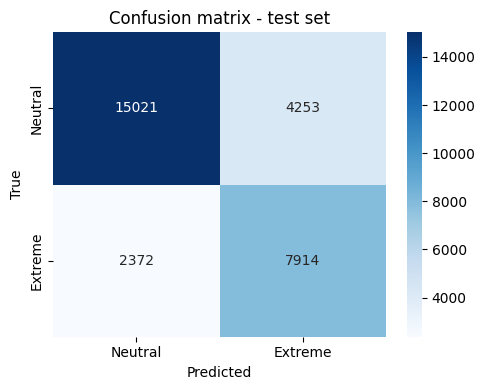


Baseline: always predict Neutral
 accuracy: 0.652  macro F1: 0.3947

Baseline: predict category's most common training-period label
 accuracy: 0.7818  macro F1: 0.7519

XGBoost model
 accuracy: 0.7759  macro F1: 0.7621


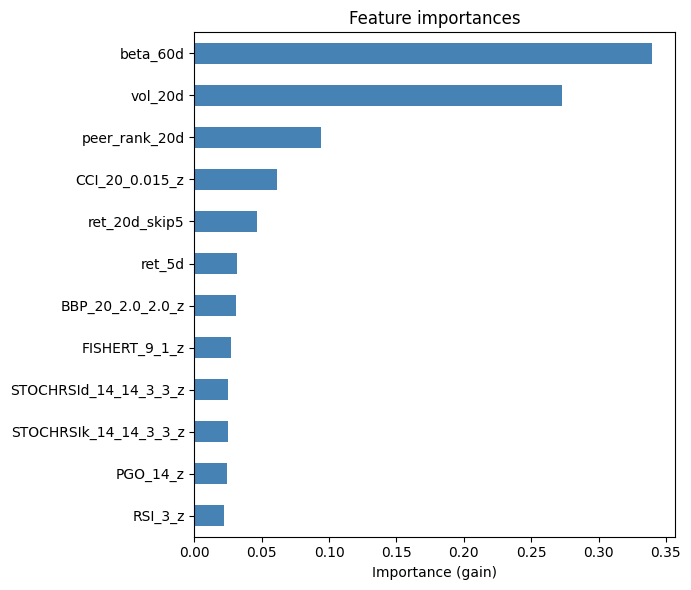

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

best_params = dict(study.best_params)
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
})

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
sw_trainval = compute_sample_weight(class_weight="balanced", y=y_trainval)

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_trainval, y_trainval, sample_weight=sw_trainval)

test_preds = final_model.predict(X_test)
target_names = ["Neutral", "Extreme"]

print("XGBoost model - test set performance")
print(classification_report(y_test, test_preds, target_names=target_names, digits=3))

cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix - test set")
plt.tight_layout()
plt.show()

baseline_neutral = np.full_like(y_test, fill_value=label_map["Neutral"])
cat_mode = train_df.groupby("category")["binary_label"].agg(lambda s: s.value_counts().idxmax())
baseline_cat = test_df["category"].map(cat_mode).map(label_map).fillna(label_map["Neutral"]).astype(int).values

print()
print("Baseline: always predict Neutral")
print(" accuracy:", round((baseline_neutral == y_test).mean(), 4), " macro F1:", round(f1_score(y_test, baseline_neutral, average="macro"), 4))

print()
print("Baseline: predict category's most common training-period label")
print(" accuracy:", round((baseline_cat == y_test).mean(), 4), " macro F1:", round(f1_score(y_test, baseline_cat, average="macro"), 4))

print()
print("XGBoost model")
print(" accuracy:", round((test_preds == y_test).mean(), 4), " macro F1:", round(f1_score(y_test, test_preds, average="macro"), 4))

feat_importance = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 6))
feat_importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance (gain)")
ax.set_title("Feature importances")
plt.tight_layout()
plt.show()

## Diagnostic: are Extreme mix-ups boundary noise or genuine magnitude errors?

Checks whether misclassified rows (true `Extreme` predicted `Neutral`, and vice versa) sit near the label boundary (`+/-0.6%`, the 15th/85th percentile cutoffs) or deep in the tail of `fwd_relative_return`. Evaluates the hypothesis that the boundary is too close to the bulk of the distribution and that this alone explains most of the confusion-matrix errors, rather than the model failing to pick up on genuinely large moves.

In [10]:
test_eval = test_df.copy()
test_eval["pred_label"] = pd.Series(test_preds, index=test_eval.index).map(inv_label_map)

flip_n2e = test_eval[(test_eval["binary_label"] == "Neutral") & (test_eval["pred_label"] == "Extreme")]
flip_e2n = test_eval[(test_eval["binary_label"] == "Extreme") & (test_eval["pred_label"] == "Neutral")]
correct_neutral = test_eval[(test_eval["binary_label"] == "Neutral") & (test_eval["pred_label"] == "Neutral")]
correct_extreme = test_eval[(test_eval["binary_label"] == "Extreme") & (test_eval["pred_label"] == "Extreme")]

print("Underperform boundary (15th pct):", round(lower_q * 100, 3), "%")
print("Outperform boundary (85th pct):", round(upper_q * 100, 3), "%")

p05 = valid_fwd.quantile(0.05)
p95 = valid_fwd.quantile(0.95)
print("5th pct (deep underperform tail):", round(p05 * 100, 3), "%")
print("95th pct (deep outperform tail):", round(p95 * 100, 3), "%")
print()

print("True Neutral -> Predicted Extreme:", len(flip_n2e), "rows")
print(" near boundary (within +/-", round((upper_q - lower_q) / 2 * 100, 3), "% of either cutoff):",
      (((flip_n2e["fwd_relative_return"] - lower_q).abs() < (upper_q - lower_q) / 2) |
       ((flip_n2e["fwd_relative_return"] - upper_q).abs() < (upper_q - lower_q) / 2)).sum(), "of", len(flip_n2e))
print()

print("True Extreme -> Predicted Neutral:", len(flip_e2n), "rows")
print(" near boundary (between 15th/85th pct and 5th/95th pct):",
      (((flip_e2n["fwd_relative_return"] >= p05) & (flip_e2n["fwd_relative_return"] < lower_q)) |
       ((flip_e2n["fwd_relative_return"] <= p95) & (flip_e2n["fwd_relative_return"] > upper_q))).sum(), "of", len(flip_e2n))
print(" deep in tail (more extreme than 5th/95th pct) yet still missed:",
      ((flip_e2n["fwd_relative_return"] < p05) | (flip_e2n["fwd_relative_return"] > p95)).sum(), "of", len(flip_e2n))
print()

print("Median |fwd_relative_return|:")
print(" correct Neutral:", round(correct_neutral["fwd_relative_return"].abs().median() * 100, 3), "% vs flipped-to-Extreme:", round(flip_n2e["fwd_relative_return"].abs().median() * 100, 3), "%")
print(" correct Extreme:", round(correct_extreme["fwd_relative_return"].abs().median() * 100, 3), "% vs flipped-to-Neutral:", round(flip_e2n["fwd_relative_return"].abs().median() * 100, 3), "%")

Underperform boundary (15th pct): -0.606 %
Outperform boundary (85th pct): 0.597 %
5th pct (deep underperform tail): -1.699 %
95th pct (deep outperform tail): 1.665 %

True Neutral -> Predicted Extreme: 4253 rows
 near boundary (within +/- 0.602 % of either cutoff): 4253 of 4253

True Extreme -> Predicted Neutral: 2372 rows
 near boundary (between 15th/85th pct and 5th/95th pct): 2105 of 2372
 deep in tail (more extreme than 5th/95th pct) yet still missed: 267 of 2372

Median |fwd_relative_return|:
 correct Neutral: 0.128 % vs flipped-to-Extreme: 0.279 %
 correct Extreme: 1.58 % vs flipped-to-Neutral: 0.882 %


## ROC AUC: Extreme vs. Neutral

ROC curve and AUC for the `Extreme` class (vs. `Neutral`), using the final model's predicted probabilities on the held-out test set.

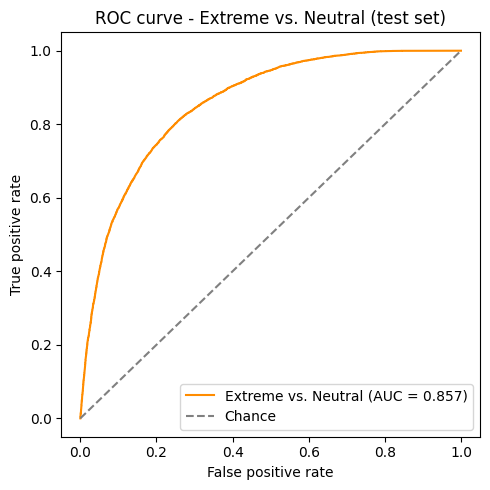

Extreme vs. Neutral ROC AUC: 0.8573


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

extreme_idx = label_map["Extreme"]
y_test_extreme = (y_test == extreme_idx).astype(int)
test_probs_extreme = final_model.predict_proba(X_test)[:, extreme_idx]

extreme_auc = roc_auc_score(y_test_extreme, test_probs_extreme)
fpr, tpr, _ = roc_curve(y_test_extreme, test_probs_extreme)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="darkorange", label=f"Extreme vs. Neutral (AUC = {extreme_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve - Extreme vs. Neutral (test set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Extreme vs. Neutral ROC AUC:", round(extreme_auc, 4))

In [12]:
final_model.save_model("20_Days_binary_extreme_classifier_ta_other.json")

## Backtest: trading the Extreme-conviction picks against SPY

The binary model predicts *magnitude* (will this fund move sharply relative to peers?), not
*direction* -- unlike the production 3-class model, it can't produce a long/short score on its
own (`P(outperform) - P(underperform)`). Here it's used as a **conviction filter** instead: each
rebalance, take the top quartile of the test-period cross-section by `P(Extreme)`, then split
that quartile into long/short by the sign of its own trailing momentum (`ret_20d_skip5`) -- the
model says "this is about to move," the momentum feature says which way.

Rebalanced every 20 trading days (matching the label horizon) over the **test period only**, so
no fold boundary is crossed. P&L uses the true absolute 20-day-forward return computed from
`close` (the source CSV only carries `fwd_relative_return` and `fwd_ret_5d`, wrong horizon and
wrong reference frame for a direct SPY comparison). Same house convention as
`notebooks/_longshort_cell.py`: turnover-costed net return, beta/alpha/correlation vs SPY, and
an equal-weight-universe line so "beat SPY" and "beat the average fund in the universe" don't get
conflated.

In [13]:
import yfinance as yf

BT_HORIZON = 20
BT_COST_BPS = 5.0

bt_df = test_df.copy()
bt_df["p_extreme"] = final_model.predict_proba(bt_df[feature_cols])[:, label_map["Extreme"]]

# True absolute forward return over the label's own horizon, computed per fund --
# not a column in the source CSV (only fwd_relative_return / fwd_ret_5d are).
bt_df = bt_df.sort_values(["fund_id", "date"])
bt_df["fwd_ret_20d_abs"] = bt_df.groupby("fund_id")["close"].shift(-BT_HORIZON) / bt_df["close"] - 1.0

rebal_dates = np.array(sorted(bt_df["date"].unique()))[::BT_HORIZON]
prev_l, prev_s, rows = set(), set(), []
for d0 in rebal_dates:
    g = bt_df[bt_df["date"] == d0].dropna(subset=["fwd_ret_20d_abs"])
    if len(g) < 8:
        continue
    q = g["p_extreme"].quantile(0.75)
    conviction = g[g["p_extreme"] >= q]
    longs = conviction[conviction["ret_20d_skip5"] > 0]
    shorts = conviction[conviction["ret_20d_skip5"] < 0]
    if len(longs) == 0 or len(shorts) == 0:
        continue
    L, S = set(longs["fund_id"]), set(shorts["fund_id"])
    turn = (len(L ^ prev_l) + len(S ^ prev_s)) / max(len(L) + len(S), 1)
    prev_l, prev_s = L, S
    rows.append({"date": d0, "n_long": len(L), "n_short": len(S),
                 "long": longs["fwd_ret_20d_abs"].mean(), "short": shorts["fwd_ret_20d_abs"].mean(),
                 "bench": g["fwd_ret_20d_abs"].mean(), "cost": turn * BT_COST_BPS / 1e4})

bt = pd.DataFrame(rows)
bt["gross"] = bt["long"] - bt["short"]
bt["net"] = bt["gross"] - bt["cost"]
print(f"{len(bt)} rebalances, {BT_HORIZON}d holds, "
      f"avg {bt['n_long'].mean():.1f} long / {bt['n_short'].mean():.1f} short "
      f"(top quartile of test-period cross-section by P(Extreme))")

spy = yf.download("SPY", start="2015-01-01", auto_adjust=True, progress=False)["Close"]
spy = (spy.iloc[:, 0] if hasattr(spy, "columns") else spy).dropna()
spy_fwd = spy.shift(-BT_HORIZON) / spy - 1.0
bt["spy"] = [spy_fwd.iloc[min(spy.index.searchsorted(pd.Timestamp(x)), len(spy) - 1)] for x in bt["date"]]
bt = bt.dropna().reset_index(drop=True)

BT_PY = 252 / BT_HORIZON
def bt_stats(r, name):
    sd = r.std()
    dd = (np.cumsum(r) - np.maximum.accumulate(np.cumsum(r))).min()
    return {"series": name, "ann": r.mean() * BT_PY, "vol": sd * np.sqrt(BT_PY),
            "sharpe": r.mean() * BT_PY / (sd * np.sqrt(BT_PY)) if sd else np.nan,
            "max_dd": dd, "hit": (r > 0).mean()}

tbl = pd.DataFrame([bt_stats(bt["net"], "long/short (net)"),
                    bt_stats(bt["long"], "long leg"),
                    bt_stats(-bt["short"], "short leg (inverted)"),
                    bt_stats(bt["spy"], "SPY"),
                    bt_stats(bt["bench"], "EW universe")]).set_index("series")
print()
print(tbl.assign(ann=tbl["ann"].map("{:+.2%}".format), vol=tbl["vol"].map("{:.2%}".format),
                 max_dd=tbl["max_dd"].map("{:.2%}".format), hit=tbl["hit"].map("{:.1%}".format),
                 sharpe=tbl["sharpe"].round(2)).to_string())

beta, alpha = np.polyfit(bt["spy"], bt["net"], 1)
corr = np.corrcoef(bt["net"], bt["spy"])[0, 1]
t_stat = bt["net"].mean() / (bt["net"].std() / np.sqrt(len(bt))) if len(bt) > 1 else np.nan
print(f"\nvs SPY: beta {beta:+.2f}  corr {corr:+.2f}  alpha {alpha*BT_PY:+.2%}/yr  t={t_stat:+.2f}")
print("A long/short book is beta-neutral by construction -- judge it on Sharpe and\n"
      "correlation to SPY, not on whether it out-returns SPY.")

7 rebalances, 20d holds, avg 30.6 long / 16.3 short (top quartile of test-period cross-section by P(Extreme))



                          ann     vol  sharpe   max_dd    hit
series                                                       
long/short (net)      +21.86%  19.94%    1.10   -7.16%  57.1%
long leg              +30.87%  15.05%    2.05   -2.82%  71.4%
short leg (inverted)   -8.39%  22.92%   -0.37  -11.62%  42.9%
SPY                   +18.45%  12.50%    1.48   -4.10%  57.1%
EW universe           +20.78%   8.56%    2.43   -2.34%  71.4%

vs SPY: beta -0.25  corr -0.16  alpha +26.49%/yr  t=+0.82
A long/short book is beta-neutral by construction -- judge it on Sharpe and
correlation to SPY, not on whether it out-returns SPY.


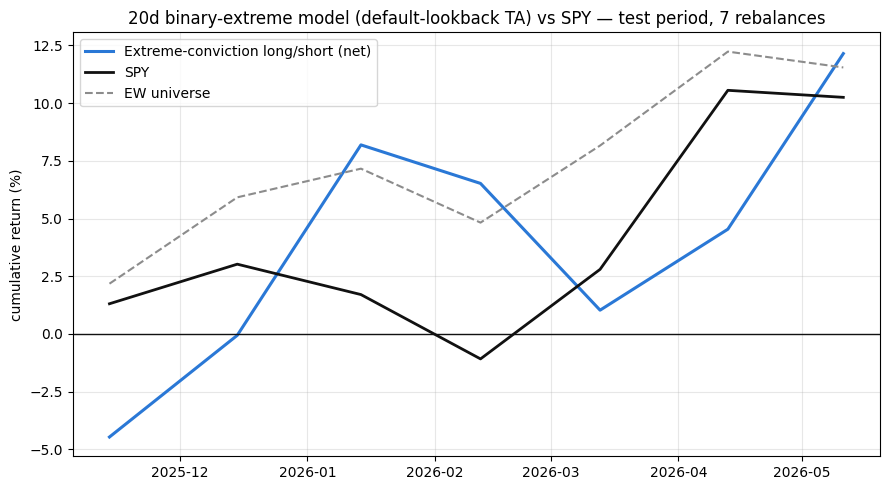

saved -> C:\Users\user\Desktop\CS\overp\outperforming\reports\20d_binary_extreme_ta_other_vs_spy.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
dt = pd.to_datetime(bt["date"])
ax.plot(dt, np.cumsum(bt["net"]) * 100, lw=2.2, color="#2a78d6", label="Extreme-conviction long/short (net)")
ax.plot(dt, np.cumsum(bt["spy"]) * 100, lw=2, color="#111111", label="SPY")
ax.plot(dt, np.cumsum(bt["bench"]) * 100, lw=1.5, ls="--", color="0.55", label="EW universe")
ax.axhline(0, color="#111111", lw=1)
ax.set_ylabel("cumulative return (%)")
ax.set_title(f"20d binary-extreme model (default-lookback TA) vs SPY — test period, {len(bt)} rebalances")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

out_path = ROOT / "reports" / "20d_binary_extreme_ta_other_vs_spy.png"
plt.savefig(out_path, dpi=150)
plt.show()
print(f"saved -> {out_path}")